In [297]:
import pandas as pd
import numpy as np
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

data = load_dataset("mstz/glass")

In [298]:
df = pd.DataFrame(data["train"][:])
df

,refractive_index,sodium,magnesium,aluminum,silicon,potassium,calcium,barium,iron,is_vehicle_glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0,0.0,0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0,0.0,0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0,0.0,0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0,0.0,0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1,0.0,0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1,0.0,0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1,0.0,0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1,0.0,0


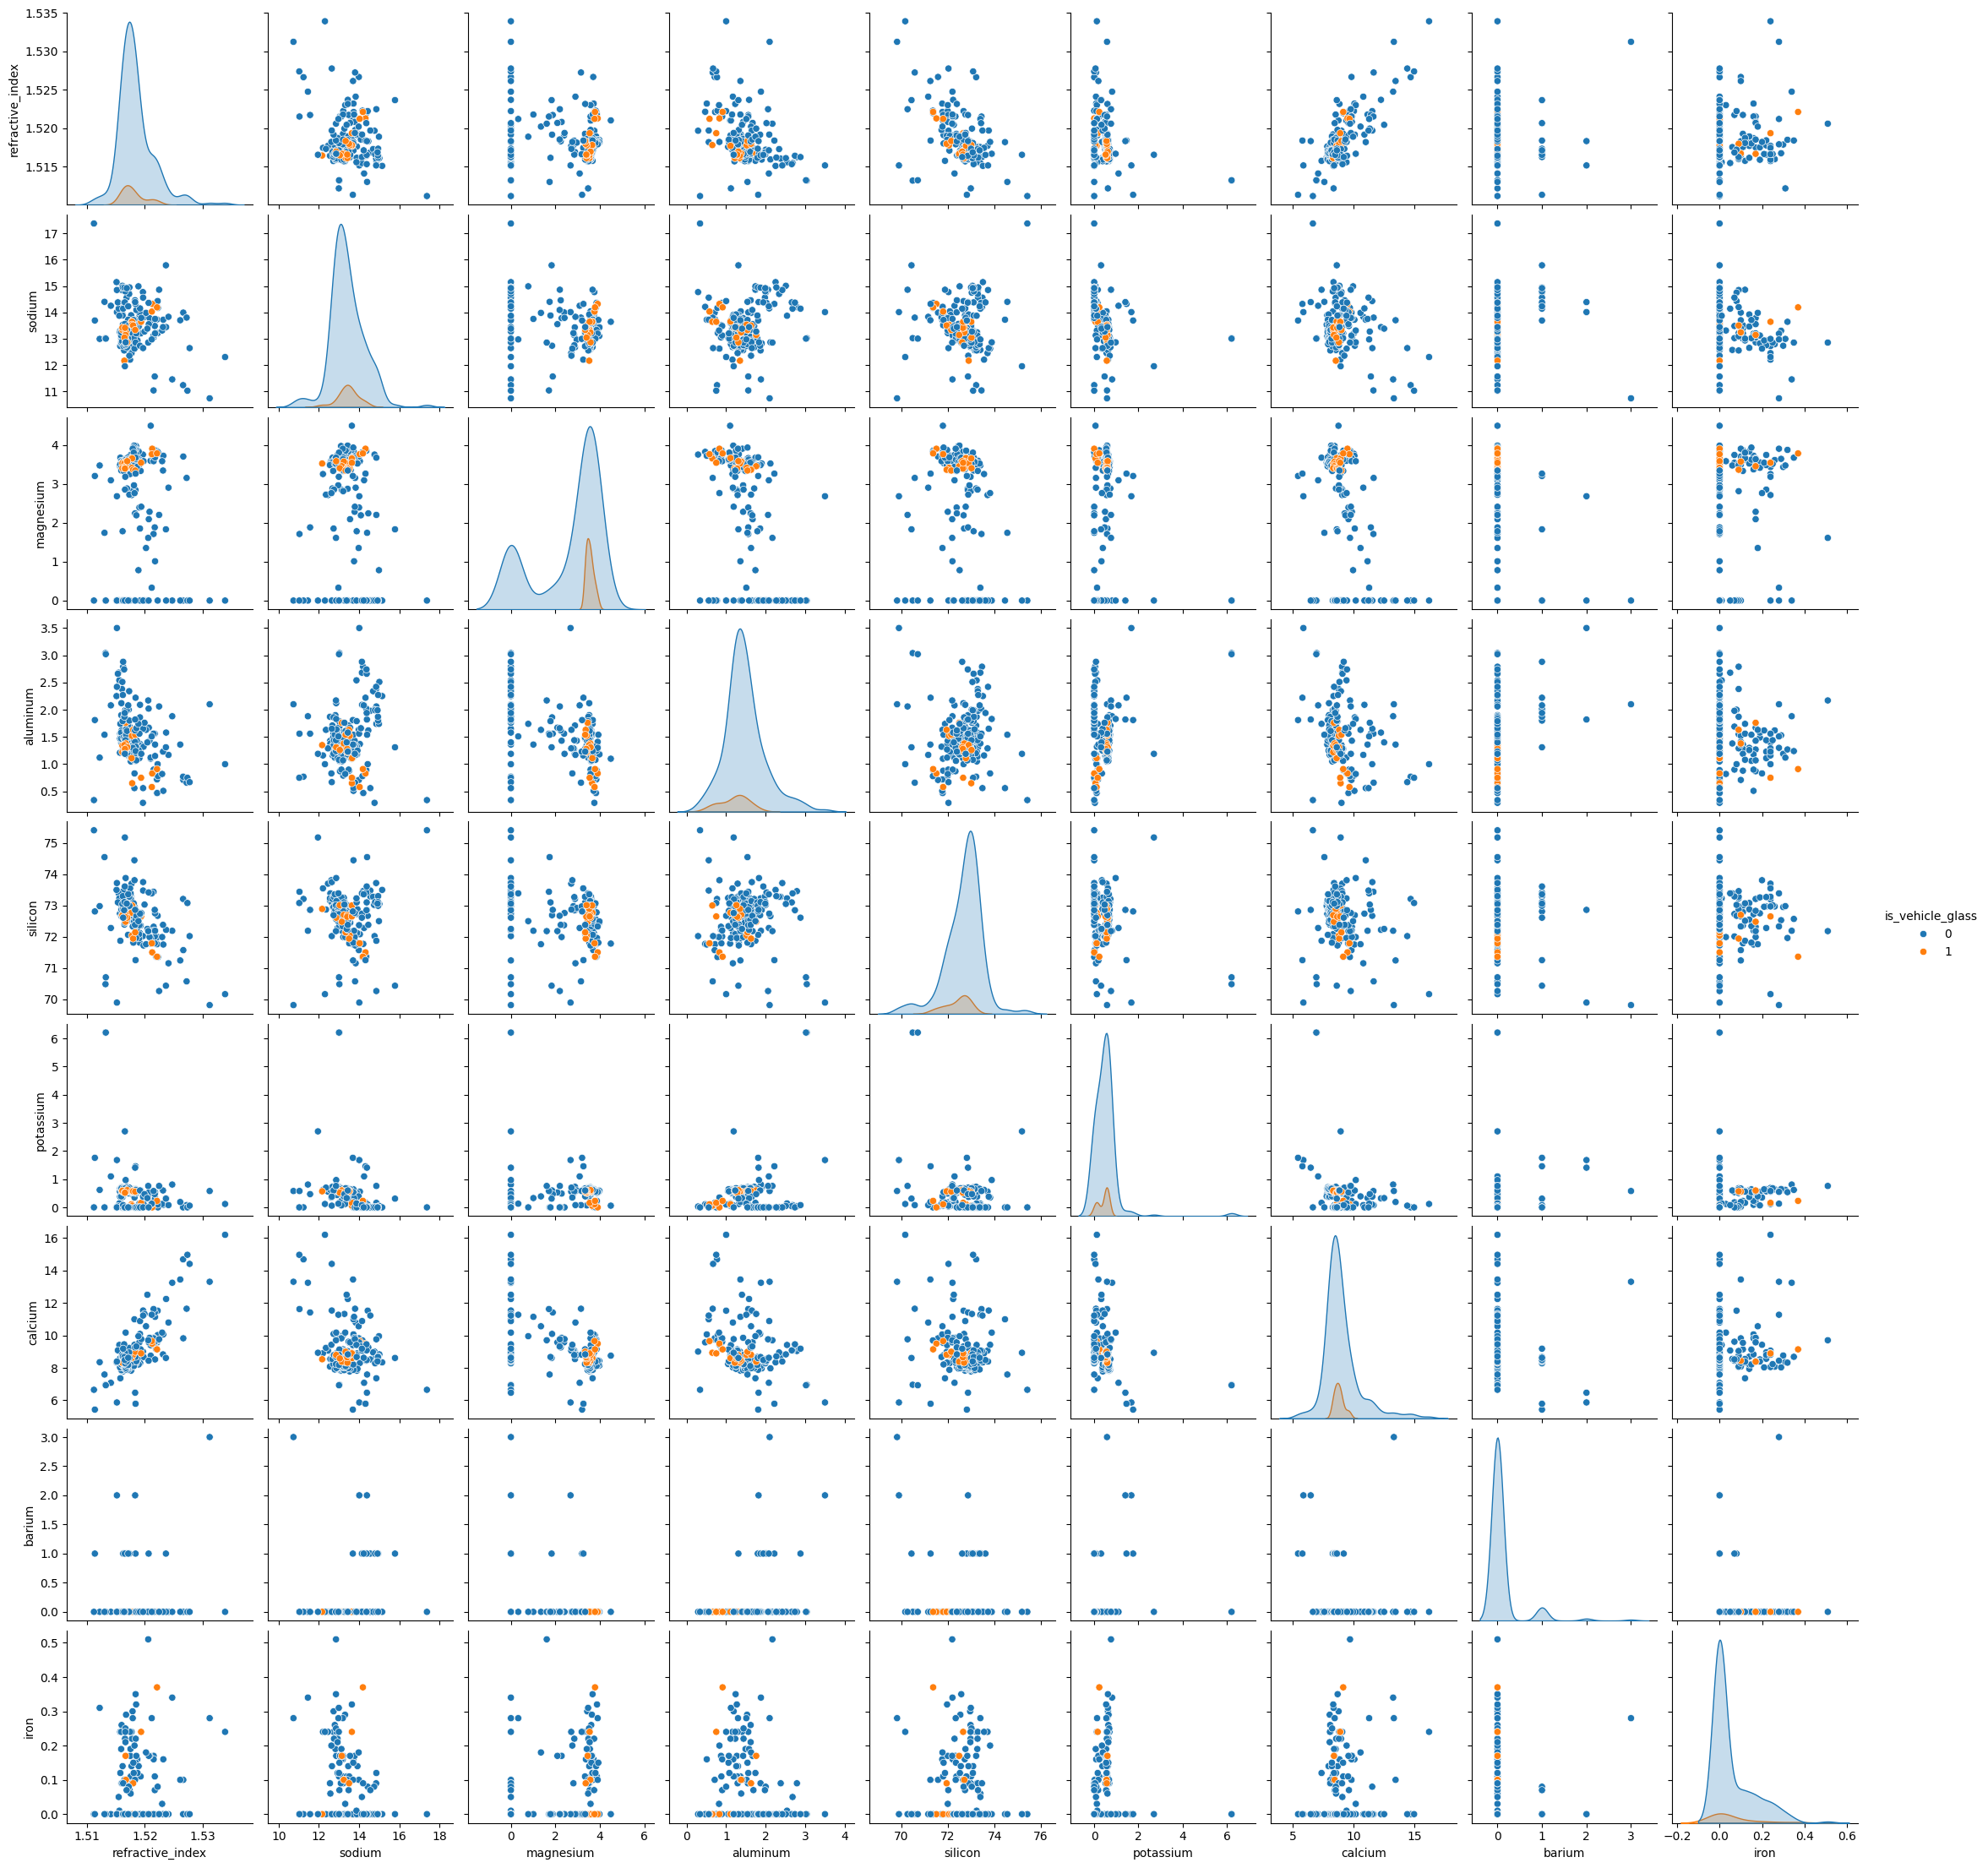

In [299]:
sns.pairplot(data=df, hue="is_vehicle_glass")

array([[<Axes: title={'center': 'refractive_index'}>,
        <Axes: title={'center': 'sodium'}>,
        <Axes: title={'center': 'magnesium'}>],
       [<Axes: title={'center': 'aluminum'}>,
        <Axes: title={'center': 'silicon'}>,
        <Axes: title={'center': 'potassium'}>],
       [<Axes: title={'center': 'calcium'}>,
        <Axes: title={'center': 'barium'}>,
        <Axes: title={'center': 'iron'}>],
       [<Axes: title={'center': 'is_vehicle_glass'}>, <Axes: >, <Axes: >]],
      dtype=object)

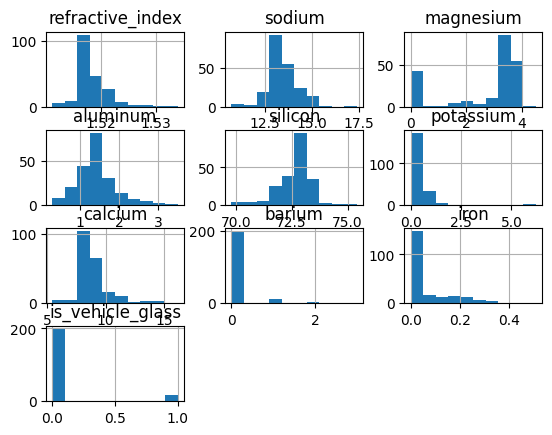

In [300]:
df.hist()

In [338]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

xall, yall = df.iloc[:, :-1].to_numpy(), df.iloc[:, -1].to_numpy()

xall = torch.tensor(xall).float()
yall = torch.tensor(yall).long()

x, xt, y, yt = train_test_split(xall, yall, test_size=0.2, random_state=67, stratify=yall)

pipe = make_pipeline(
    StandardScaler(),
    # PowerTransformer(),
    # StandardScaler(),
    # PCA(n_components=4),
    # StandardScaler(),
    # PowerTransformer(),
    # StandardScaler()
)
x = torch.tensor(pipe.fit_transform(x)).float()

<Axes: xlabel='None', ylabel='None'>

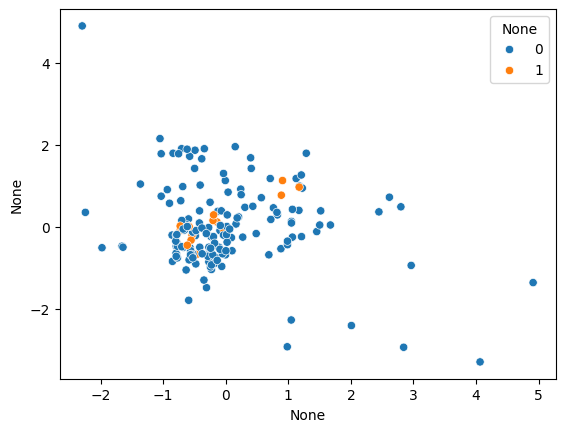

In [339]:
sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y)

In [340]:
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(67)
td = TensorDataset(x, y)
dl = DataLoader(td, batch_size=16, shuffle=True)

In [341]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(9, 32)
    self.act1 = nn.SiLU()
    self.layer2 = nn.Linear(32, 2)
    self.act2 = nn.Identity()

  def forward(self, x):
    a1 = self.act1(self.layer1(x))
    a2 = self.layer2(a1)
    return a2

torch.manual_seed(67)
model = Model()

In [342]:
lossf = nn.CrossEntropyLoss()
optim = torch.optim.SGD(model.parameters(), lr=0.01)
hist = []

for epoch in range(100):
  curloss = 0
  for xb, yb in dl:
    optim.zero_grad()
    out = model(xb)
    loss = lossf(out, yb)
    loss.backward()
    optim.step()
    curloss += loss.item()
  hist.append(curloss / len(dl))

  if epoch % 10 == 0:
    print(f"Epoch {epoch} | Loss = {hist[-1]:.3f}")

Epoch 0 | Loss = 0.650
Epoch 10 | Loss = 0.378
Epoch 20 | Loss = 0.313
Epoch 30 | Loss = 0.294
Epoch 40 | Loss = 0.277
Epoch 50 | Loss = 0.271
Epoch 60 | Loss = 0.271
Epoch 70 | Loss = 0.263
Epoch 80 | Loss = 0.260
Epoch 90 | Loss = 0.257


<Axes: >

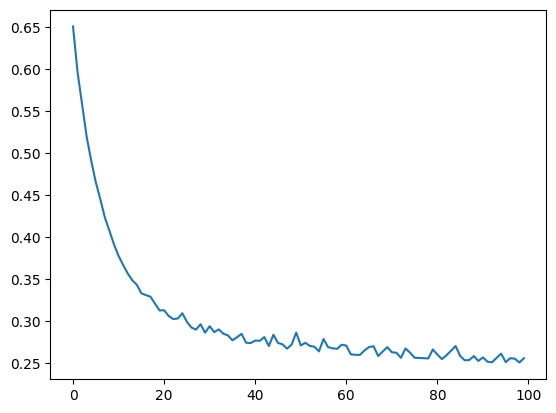

In [343]:
sns.lineplot(x=np.arange(len(hist)), y=hist)

In [349]:
xt = torch.tensor(pipe.transform(xt)).float()

model.eval()
with torch.no_grad():
  logits = model(xt)
  pred = torch.argmax(logits, dim=1)

numtrue = (yt == pred).sum()
numall = len(yt)

print(f"Acc = {numtrue / numall}")

Acc = 0.930232584476471
